# Applying Az-Calculus to quantum circuits using PennyLane and pyzx python library

this is a simple tutorial made for the Quantum Computing course __[Quantum Computing course](https://www.unibo.it/it/studiare/insegnamenti-competenze-trasversali-moocs/insegnamenti/insegnamento/2025/535208/orariolezioni)__

we will apply [PennyLane](https://pennylane.ai/) "a cross-platform Python library for quantum computing, quantum machine learning" togother with [PyZX](https://pyzx.readthedocs.io/en/latest/quickintro.html) "an open-source Python library used for analyzing, optimizing, and visualizing quantum circuits using ZX-calculus".

## First we install and import the needed libraries:

In [8]:
pip install pennylane

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install pyzx

Note: you may need to restart the kernel to use updated packages.


In [10]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
import pyzx
import math

### The note book will have the following structure:

 - define a device on which the quantum ciurcit will run.
 - define a quantum function that returns Qnode object.
 - visualize the circuit using standard symbols.
 - visualize the circuit using zx-diagrams.
 - reduce (or try to) thecomplixity of the zx-diagram.
 - optimize it.
 - show the number of gates for the optimized circuit and the orginal one.
 - run it to verify equivilance.

### Define the device

Two devices are defined: based on the number of wires used.

In [13]:
dev_5 = qml.device('default.qubit', wires=5)
dev_4 = qml.device('default.qubit', wires=4)

now we define the quantum functions that contain the gates applied on bits in state zero:

In [14]:
@qml.set_shots(None)
@qml.qnode(dev_4)
def quantum_circuit_4():
    qml.H(wires=2)
    qml.S(wires=2)
    qml.CNOT(wires=[2,3])
    qml.CNOT(wires=[0,2])
    qml.CNOT(wires=[1,3])
    qml.CNOT(wires=[3,1])
    qml.CNOT(wires=[1,0])
    qml.H(wires=1)
    qml.CNOT(wires=[2,1])
    qml.CNOT(wires=[3,2])
    qml.CNOT(wires=[3,1])
    qml.CNOT(wires=[0,2])
    qml.S(wires=1)
    qml.CNOT(wires=[0,1])
    return qml.probs(wires=[0,1,2,3])

In [15]:
@qml.set_shots(None)
@qml.qnode(dev_5)
def quantum_circuit_5_max_entaglment():
    qml.Hadamard(wires=0),
    qml.CNOT(wires=[0, 1]),
    qml.CNOT(wires=[1, 2]),
    qml.CNOT(wires=[2, 3]),
    qml.CNOT(wires=[3, 4]),
    return qml.probs(wires=[0,1,2,3,4])

In [16]:
@qml.set_shots(None)
@qml.qnode(dev_5)
def quantum_circuit_5_random():
    qml.PauliX(wires=4),
    qml.Hadamard(wires=4),
    qml.CNOT(wires=[3, 4]),
    qml.adjoint(qml.T(wires=[4])),
    qml.CNOT(wires=[0, 4]),
    qml.T(wires=[4]),
    qml.CNOT(wires=[3, 4]),
    qml.adjoint(qml.T(wires=[4])),
    qml.CNOT(wires=[0, 4]),
    qml.T(wires=[3]),
    qml.T(wires=[4]),
    qml.CNOT(wires=[0, 3]),
    qml.T(wires=[0]),   
    qml.adjoint(qml.T(wires=[3]))
    qml.CNOT(wires=[0, 3]),
    qml.CNOT(wires=[3, 4]),
    qml.adjoint(qml.T(wires=[4])),
    qml.CNOT(wires=[2, 4]),
    qml.T(wires=[4]),
    qml.CNOT(wires=[3, 4]),
    qml.adjoint(qml.T(wires=[4])),
    qml.CNOT(wires=[2, 4]),
    qml.T(wires=[3]),
    qml.T(wires=[4]),
    qml.CNOT(wires=[2, 3]),
    qml.T(wires=[2]),
    qml.adjoint(qml.T(wires=[3]))
    qml.CNOT(wires=[2, 3]),
    qml.Hadamard(wires=[4]),
    qml.CNOT(wires=[3, 4]),
    qml.Hadamard(wires=4),
    qml.CNOT(wires=[2, 4]),
    qml.adjoint(qml.T(wires=[4])),
    qml.CNOT(wires=[1, 4]),
    qml.T(wires=[4]),
    qml.CNOT(wires=[2, 4]),
    qml.adjoint(qml.T(wires=[4])),
    qml.CNOT(wires=[1, 4]),
    qml.T(wires=[4]),
    qml.T(wires=[2]),
    qml.CNOT(wires=[1, 2]),
    qml.T(wires=[1]),
    qml.adjoint(qml.T(wires=[2]))
    qml.CNOT(wires=[1, 2]),
    qml.Hadamard(wires=[4]),
    qml.CNOT(wires=[2, 4]),
    qml.Hadamard(wires=4),
    qml.CNOT(wires=[1, 4]),
    qml.adjoint(qml.T(wires=[4])),
    qml.CNOT(wires=[0, 4]),
    qml.T(wires=[4]),
    qml.CNOT(wires=[1, 4]),
    qml.adjoint(qml.T(wires=[4])),
    qml.CNOT(wires=[0, 4]),
    qml.T(wires=[4]),
    qml.T(wires=[1]),
    qml.CNOT(wires=[0, 1]),
    qml.T(wires=[0]),
    qml.adjoint(qml.T(wires=[1])),
    qml.CNOT(wires=[0, 1]),
    qml.Hadamard(wires=[4]),
    qml.CNOT(wires=[1, 4]),
    qml.CNOT(wires=[0, 4]),
    return qml.probs(wires=[0,1,2,3,4])

Let's choose one of them (now the notebook is set to use quantum_circuit_5_random):

### Visulize the circuit in standard way:

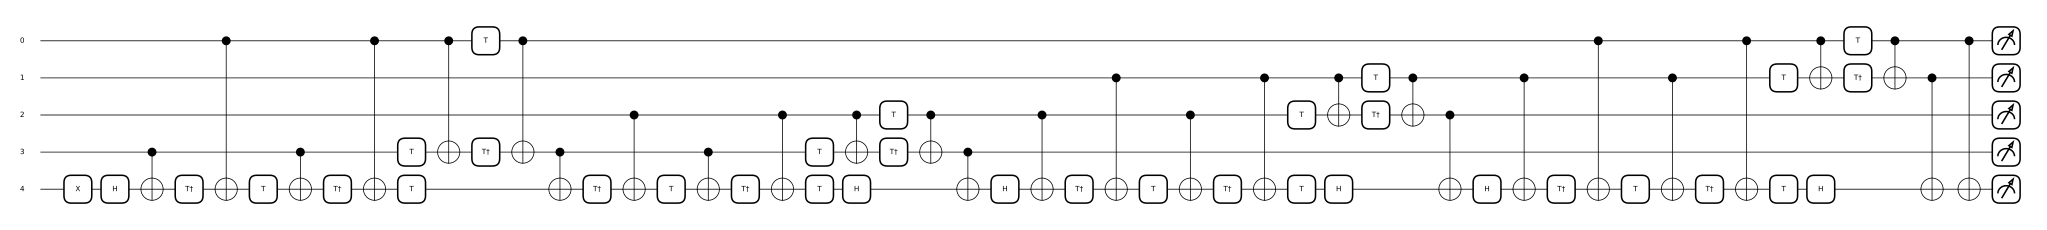

In [27]:
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(quantum_circuit_5_random)()
plt.show()

### visualize the circuit as a zx-digram:

transfer it to zx domain:

In [28]:
zx_quantum_circuit = qml.transforms.to_zx(quantum_circuit_5_random)
zx_quantum_circuit = zx_quantum_circuit()

Display it as a zx-diagram(blue lines are hadamard gates):

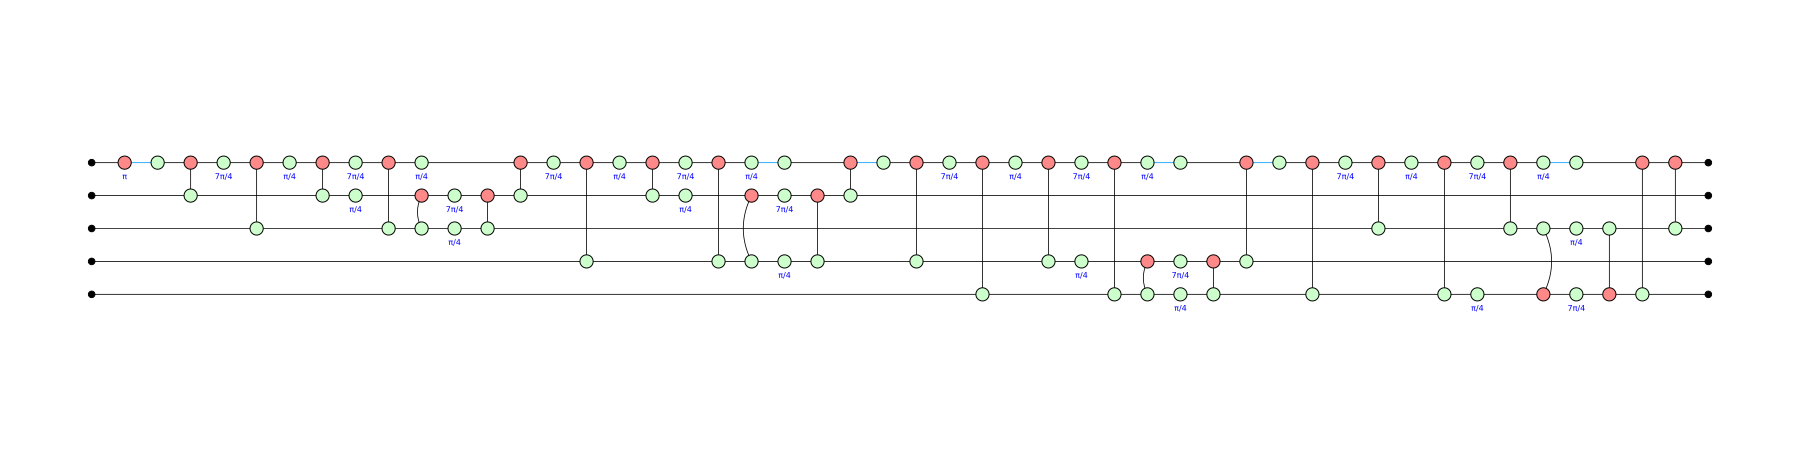

In [35]:
fig = pyzx.draw_matplotlib(zx_quantum_circuit, h_edge_draw='blue', figsize=(32,8))

manager = plt.figure().canvas.manager
manager.canvas.figure = fig
fig.set_canvas(manager.canvas)
plt.show()

### Apply the rewriting rules of zx-calculus to reduce the graph:

In [38]:
zx_quantum_circuit_simplified = zx_quantum_circuit.copy()

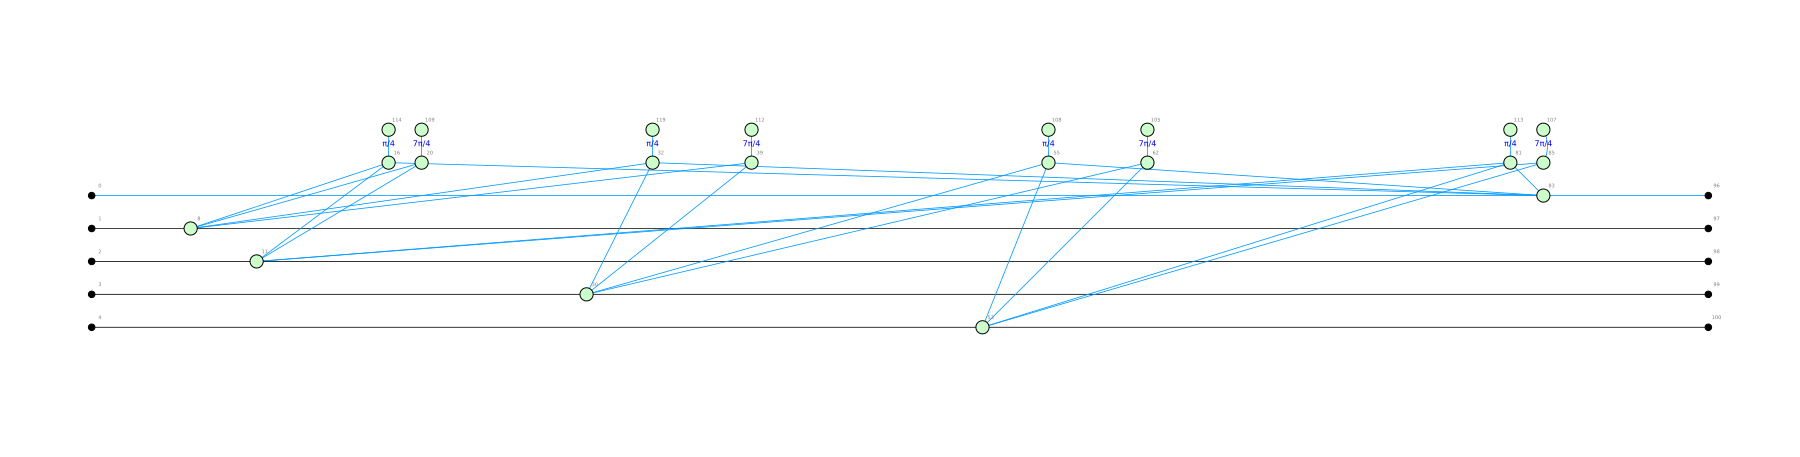

In [39]:
pyzx.simplify.full_reduce(zx_quantum_circuit_simplified)
fig = pyzx.draw_matplotlib(zx_quantum_circuit_simplified, h_edge_draw='blue', labels=True,  figsize=(32,8))

manager = plt.figure().canvas.manager
manager.canvas.figure = fig
fig.set_canvas(manager.canvas)
plt.show()

now we have spiders with multiple legs(this might result in a ciruit that is not transfelable to the normal domain so extracting the ciurcit after reducing it is advised)

### Apply optimization algorithm given by Pyzx library

extract the ciurcit:

In [40]:
extracted_ciurcit_simplified = pyzx.extract_circuit(zx_quantum_circuit_simplified.copy())

visualize it again and notice the multiple leged spiders are no more(now they are 2 in 2 out maximum)

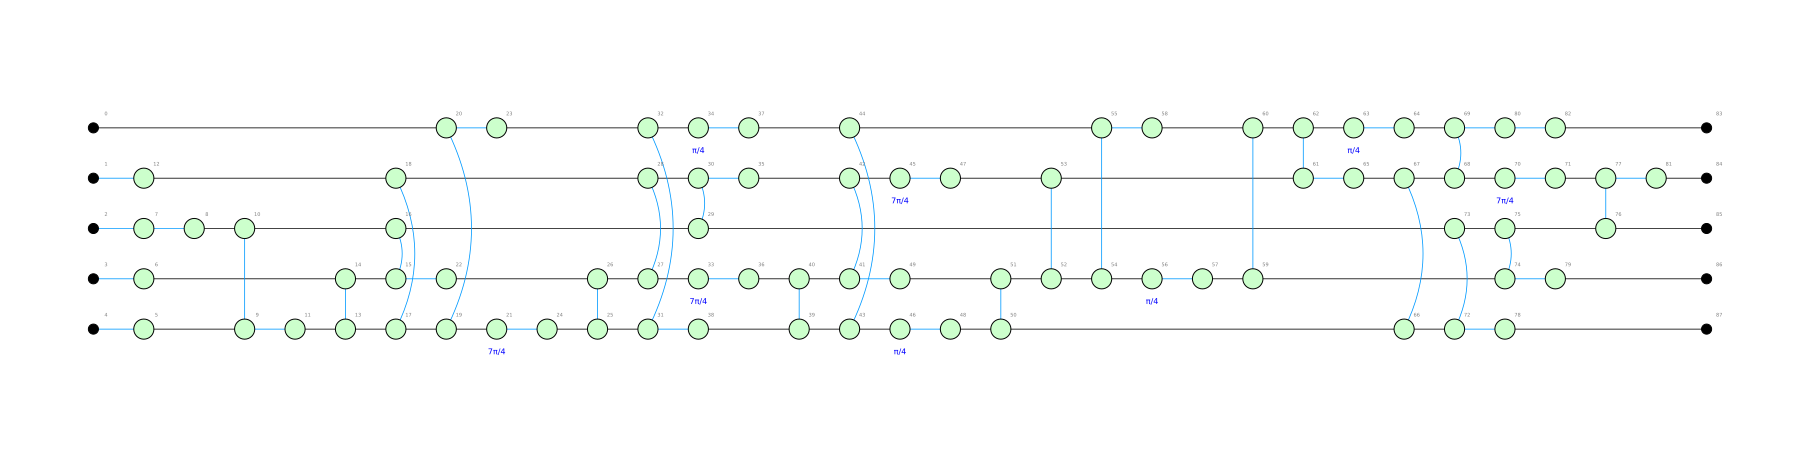

In [41]:
fig = pyzx.draw_matplotlib(extracted_ciurcit_simplified, h_edge_draw='blue', labels=True,  figsize=(32,8))
manager = plt.figure().canvas.manager
manager.canvas.figure = fig
fig.set_canvas(manager.canvas)

Apply the optimization algorithm

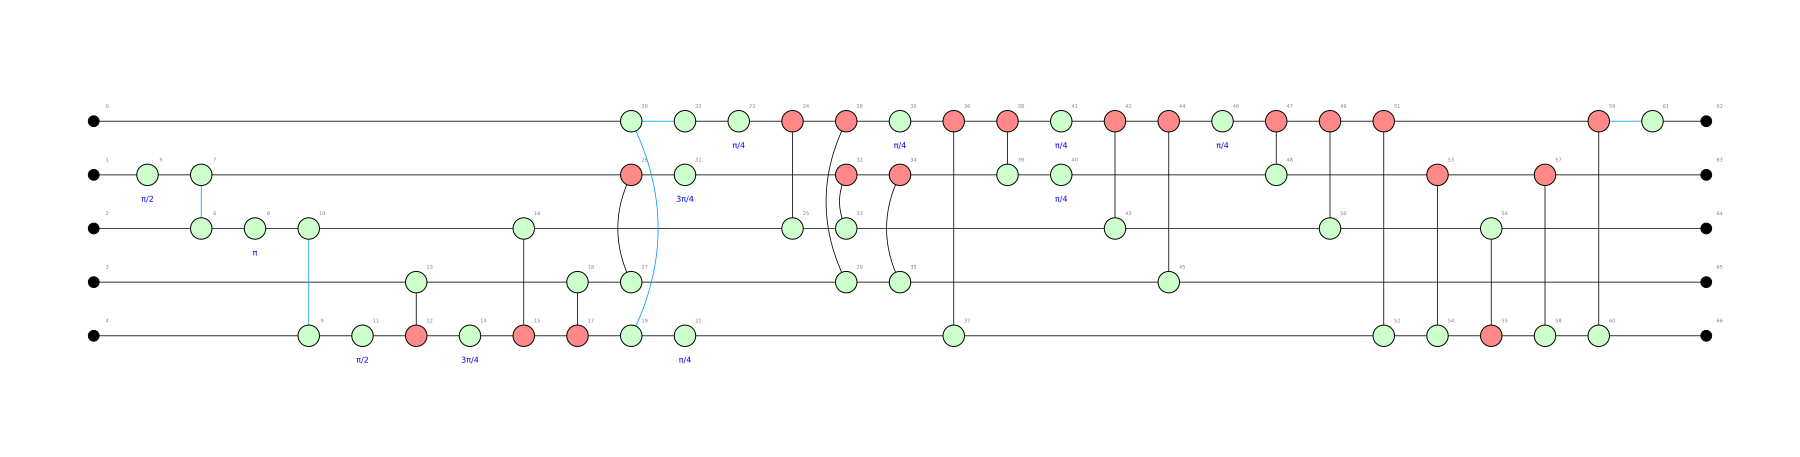

In [42]:
optimized_extracted_ciurcit_simplified = pyzx.optimize.full_optimize(extracted_ciurcit_simplified.copy())
fig = pyzx.draw_matplotlib(optimized_extracted_ciurcit_simplified, h_edge_draw='blue', labels=True,  figsize=(32,8))

# The following lines are added because the figure is automatically closed by PyZX.
manager = plt.figure().canvas.manager
manager.canvas.figure = fig
fig.set_canvas(manager.canvas)

### Visulize the ciurcit in standard way:

/tmp/ipykernel_7800/3643319593.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


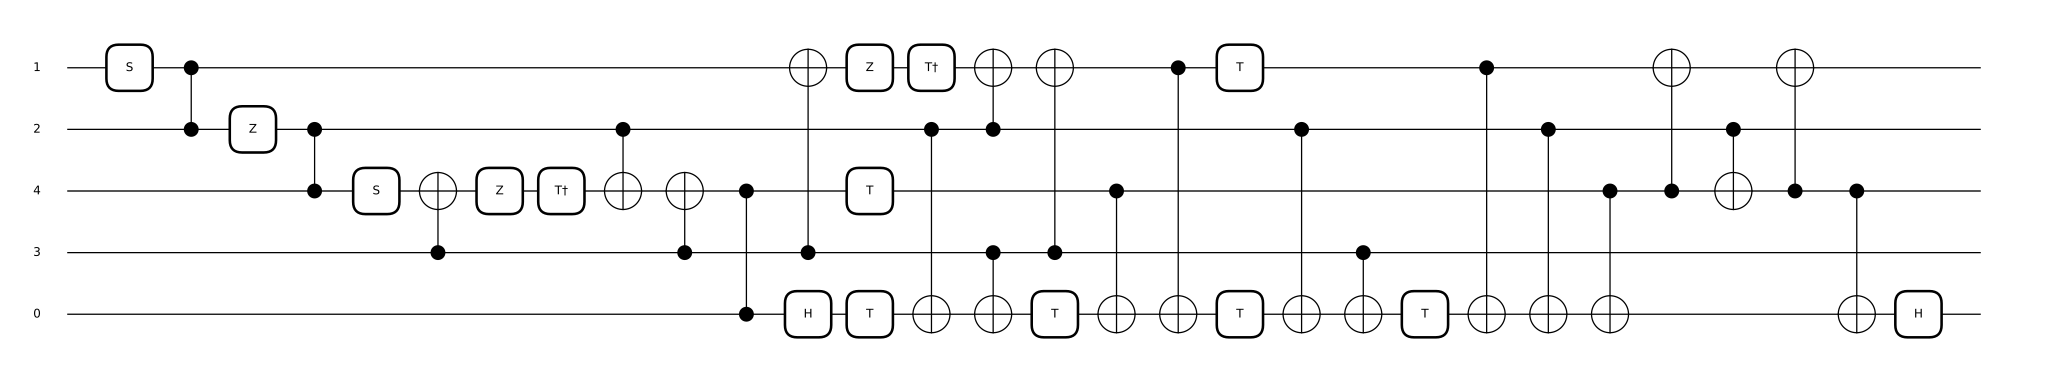

In [43]:
optimized_simplified_tape = qml.transforms.from_zx(optimized_extracted_ciurcit_simplified.to_graph())
fig, ax = qml.drawer.tape_mpl(optimized_simplified_tape)
fig.show()

### Produce the quantum script of the optimized ciurcit to be run on a device:

In [44]:
qscript_opt_smp = qml.tape.QuantumScript(optimized_simplified_tape, [qml.probs(wires=[1,2,4,3,0])])

run the script:

In [46]:
res = qml.execute(tapes = [qscript_opt_smp], device = dev_5, diff_method=None)

define a helper function to print the result:

In [47]:
def get_result(arr):
    out = []
    n =len(arr)
    m = math.sqrt(n)
    n = int(n)
    for i in range(n):
        x = int(m -len(bin(i)[2:]))
        binary_str_no_prefix = x * "0"
        binary_str_no_prefix = binary_str_no_prefix + bin(i)[2:]
        out.append(binary_str_no_prefix)
    out = dict(zip(out, arr))
    return out

In [48]:
def print_dict_rows(dictionary):
    """Print each key-value pair on a separate row"""
    for key, value in dictionary.items():
        print(f"{key}: {value}")

Print the results of the optimized ciurcit:

In [51]:
print_dict_rows(get_result(res[0]))

00000: 2.6169969609991065e-32
00001: 0.9999999999999996
00010: 0.0
00011: 0.0
00100: 0.0
00101: 0.0
00110: 0.0
00111: 0.0
01000: 0.0
01001: 0.0
01010: 0.0
01011: 0.0
01100: 0.0
01101: 0.0
01110: 0.0
01111: 0.0
10000: 0.0
10001: 0.0
10010: 0.0
10011: 0.0
10100: 0.0
10101: 0.0
10110: 0.0
10111: 0.0
11000: 0.0
11001: 0.0
11010: 0.0
11011: 0.0
11100: 0.0
11101: 0.0
11110: 0.0
11111: 0.0


### run the ciurcit before optimization:

In [52]:
print_dict_rows(get_result(quantum_circuit_5_random()))

00000: 2.267763367533341e-35
00001: 0.9999999999999991
00010: 0.0
00011: 0.0
00100: 0.0
00101: 0.0
00110: 0.0
00111: 0.0
01000: 0.0
01001: 0.0
01010: 0.0
01011: 0.0
01100: 0.0
01101: 0.0
01110: 0.0
01111: 0.0
10000: 0.0
10001: 0.0
10010: 0.0
10011: 0.0
10100: 0.0
10101: 0.0
10110: 0.0
10111: 0.0
11000: 0.0
11001: 0.0
11010: 0.0
11011: 0.0
11100: 0.0
11101: 0.0
11110: 0.0
11111: 0.0


### we verified the same output now let's look into the number of gates:

 - before applying transformation and optimization:

In [53]:
specs_func = qml.specs(quantum_circuit_5_random)
specs_func()

{'resources': Resources(num_wires=5, num_gates=63, gate_types=defaultdict(<class 'int'>, {'PauliX': 1, 'Hadamard': 6, 'CNOT': 28, 'Adjoint(T)': 12, 'T': 16}), gate_sizes=defaultdict(<class 'int'>, {1: 35, 2: 28}), depth=48, shots=Shots(total_shots=None, shot_vector=())),
 'errors': {},
 'num_observables': 1,
 'num_trainable_params': 0,
 'num_device_wires': 5,
 'num_tape_wires': 5,
 'device_name': 'default.qubit',
 'level': 'gradient',
 'gradient_options': {},
 'interface': 'auto',
 'diff_method': 'best',
 'gradient_fn': 'backprop'}

 - after applying optimization:

In [54]:
qscript_opt_smp.specs

{'resources': Resources(num_wires=5, num_gates=37, gate_types=defaultdict(<class 'int'>, {'S': 2, 'CZ': 3, 'PauliZ': 3, 'CNOT': 19, 'Adjoint(T)': 2, 'T': 6, 'Hadamard': 2}), gate_sizes=defaultdict(<class 'int'>, {1: 15, 2: 22}), depth=30, shots=Shots(total_shots=None, shot_vector=())),
 'errors': {},
 'num_observables': 1,
 'num_trainable_params': 0}

### Final notes:
 - we managed to apply a transformation resulting in the same output.
 - a different number of gates and depth is noticed as a result of the transformation(reducing + optimization).
 - the transformation does not result always in a reduction in depth and number of gates,

feel free to open an issue on this repository for any questions :)